Initial theta1 = 2.7094638680079246
Initial theta2 = 3.7547749088981326
Initial cost   = -0.39901601064729636
Step   0 | Cost = -0.399016 | Theta1 = 2.709464 | Theta2 = 3.754775 | Grad1 = -0.908076 | Grad2 = 0.575473
Step   1 | Cost = -0.630596 | Theta1 = 2.891079 | Theta2 = 3.639680 | Grad1 = -0.968785 | Grad2 = 0.477746
Step   2 | Cost = -0.863344 | Theta1 = 3.084836 | Theta2 = 3.544131 | Grad1 = -0.998390 | Grad2 = 0.391755
Step   3 | Cost = -1.090345 | Theta1 = 3.284514 | Theta2 = 3.465780 | Grad1 = -0.989804 | Grad2 = 0.318539
Step   4 | Cost = -1.300585 | Theta1 = 3.482475 | Theta2 = 3.402072 | Grad1 = -0.942460 | Grad2 = 0.257544
Step   5 | Cost = -1.483238 | Theta1 = 3.670967 | Theta2 = 3.350563 | Grad1 = -0.863123 | Grad2 = 0.207453
Step   6 | Cost = -1.631753 | Theta1 = 3.843592 | Theta2 = 3.309073 | Grad1 = -0.763553 | Grad2 = 0.166698
Step   7 | Cost = -1.745397 | Theta1 = 3.996302 | Theta2 = 3.275733 | Grad1 = -0.656438 | Grad2 = 0.133739
Step   8 | Cost = -1.828062 | Thet

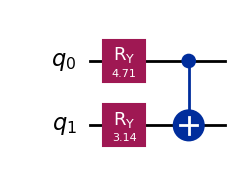


Optimized variational state:


<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.circuit.library import UnitaryGate
from numpy import pi
from qiskit_aer import AerSimulator
import numpy as np
import math
import random


# Cost circuit

def make_circuit(theta1,theta2):
    qc = QuantumCircuit(2)
    # The choice of Ansatz depends...basically here we have taken a 
    # Hamiltonian that couples |10> with |01> so we have taken a cx also..
    
    qc.ry(theta1, 0)
    qc.ry(theta2, 1)
    qc.cx(0,1)

    return qc



# Cost function
# We take cost = <Z0>


def cost(theta1, theta2):
    qc = make_circuit(theta1, theta2)

    state = Statevector.from_instruction(qc)

    X = Operator([[0, 1],
                  [1, 0]])

    Z = Operator([[1, 0],
                  [0, -1]])

    I = Operator([[1, 0],
                  [0, 1]])

    H = Z.tensor(Z) + X.tensor(X)

    new_state = state.evolve(H)

    value = state.inner(new_state)

    return np.real(value)


# Parameter Shift Rule

def psr_gradient(theta1, theta2):

    # dC/dtheta1
    grad1 = (
        cost(theta1 + pi/2, theta2)
        - cost(theta1 - pi/2, theta2)
    ) / 2

    # dC/dtheta2
    grad2 = (
        cost(theta1, theta2 + pi/2)
        - cost(theta1, theta2 - pi/2)
    ) / 2

    return grad1, grad2



# Gradient Descent


theta1 = random.uniform(0, 2*pi)
theta2 = random.uniform(0, 2*pi)

eta = 0.2

max_iter = 100
tol = 1e-6

print("Initial theta1 =", theta1)
print("Initial theta2 =", theta2)
print("Initial cost   =", cost(theta1, theta2))

for step in range(max_iter):

    grad1, grad2 = psr_gradient(theta1, theta2)

    theta1_new = theta1 - eta*grad1
    theta2_new = theta2 - eta*grad2

    c_old = cost(theta1, theta2)
    c_new = cost(theta1_new, theta2_new)

    print(
        f"Step {step:3d} | "
        f"Cost = {c_old:.6f} | "
        f"Theta1 = {theta1:.6f} | "
        f"Theta2 = {theta2:.6f} | "
        f"Grad1 = {grad1:.6f} | "
        f"Grad2 = {grad2:.6f}"
    )

    # Better convergence criterion
    if abs(grad1) < tol and abs(grad2) < tol:
        print("\nConverged.")
        theta1 = theta1_new
        theta2 = theta2_new
        break

    theta1 = theta1_new
    theta2 = theta2_new


print("\nFinal theta1 =", theta1)
print("Final theta2 =", theta2)
print("Final cost   =", cost(theta1, theta2))

# Optimized variational state


final_circuit = make_circuit(theta1, theta2)

display(final_circuit.draw(output="mpl"))

final_state = Statevector.from_instruction(final_circuit)

print("\nOptimized variational state:")

display(final_state.draw("latex"))